In [15]:
import pandas as pd


import matplotlib.pyplot as plt
import numpy as np



from handcalcs import *
from handcalcs import render
import handcalcs

## PCB alowed current 
### Formula

In [46]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1


# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [47]:
# oz to thinknes
# 1 oz ==> 1 oz of cupper by ft2
# 8,96 g/cm³ cupper
# 1 oz = 28,3495g
# 1ft = 30,48 cm
def oz_um_cal (oz):
  massekg = oz *28.3495/1e3
  # volum = area * thicknesss
  aream2 = (30.48*1e-2)**2
  rocukgm3= 8718 # this value is ajuste to found 105µm for 3 oz
  volumm3 = massekg/rocukgm3
  thickness= volumm3/aream2
  thicknessum= thickness*1e6
  return thicknessum
oz_um = {}
for oz in [0.5,1,2, 3]:
  thicknessum = oz_um_cal (oz)
  #print(f"# {oz:.1f} oz ==> {thicknessum:.1f} µm")
  oz_um[oz]= thicknessum

# 0.5 oz ==> 17.50 µm
# 1.0 oz ==> 35.00 µm
# 2.0 oz ==> 70.00 µm
# 3.0 oz ==> 105.01 µm

# you can check again in
# https://pcbprime.com/pcb-tips/how-thick-is-1oz-copper/
#print(oz_um)


In [48]:
K=Delta_T=A=1 # juste to initial var

$ I = K \cdot \left( \Delta_{T} \right) ^{ 0.44 } \cdot \left( A \right) ^{ 0.725 } $

Where :

In [52]:
%%render symbolic
I # Current (A)
A # Cross section in seq. mils
Delta_T # Temperature rise in °C

<IPython.core.display.Latex object>

In [50]:
%%render 
K = 0.048 # Outer layer 
K = 0.048 # Inner layer 

<IPython.core.display.Latex object>

See PC-2221A(L), page 50

<img src = "figs/PCB_current.png">

In [3]:
def ipc2221current(wmm, thicknessum, DT= 30, kind = "outer"):
    # IPC-2221A page 50 formula max current of pcb
  wmil =wmm /0.0254
    # mm to milis, converting thickness in micrometers (µm) to mils (thousandths of an inch).
    # 1 mil=0.001 inch
    # 1 inch = 25.4 mm= 25400 um
  thmil = thicknessum /(0.0254*1000)
  areamils = wmil*thmil
  #print2(areamils)
  if kind =="outer":
    k = 0.048
  if kind =="inner":
    k = 0.024
  I = k*(DT**0.44) *(areamils**0.725)
  return I

In [4]:
def ipc2221_min_width(I, thicknessum, DT= 30, kind = "outer"):
    # IPC-2221A page 50 formula max current of pcb
    
    # mm to milis, converting thickness in micrometers (µm) to mils (thousandths of an inch).
    # 1 mil=0.001 inch
    # 1 inch = 25.4 mm= 25400 um
    thmil = thicknessum /(0.0254*1000)

    #print2(areamils)
    if kind =="outer":
        k = 0.048
    if kind =="inner":
        k = 0.024
    
    #I = k*(DT**0.44) *(areamils**0.725)
    areamils = (I / (k * (DT**0.44)))**(1/0.725)
    # areamils = wmil*thmil
    wmil= areamils/thmil
    #wmil =wmm /0.0254
    wmm= wmil*0.0254
    return wmm

Below an application of this formula for outer / inner layers

Text(0, 0.5, 'Trace width (mm)\nInner Layer')

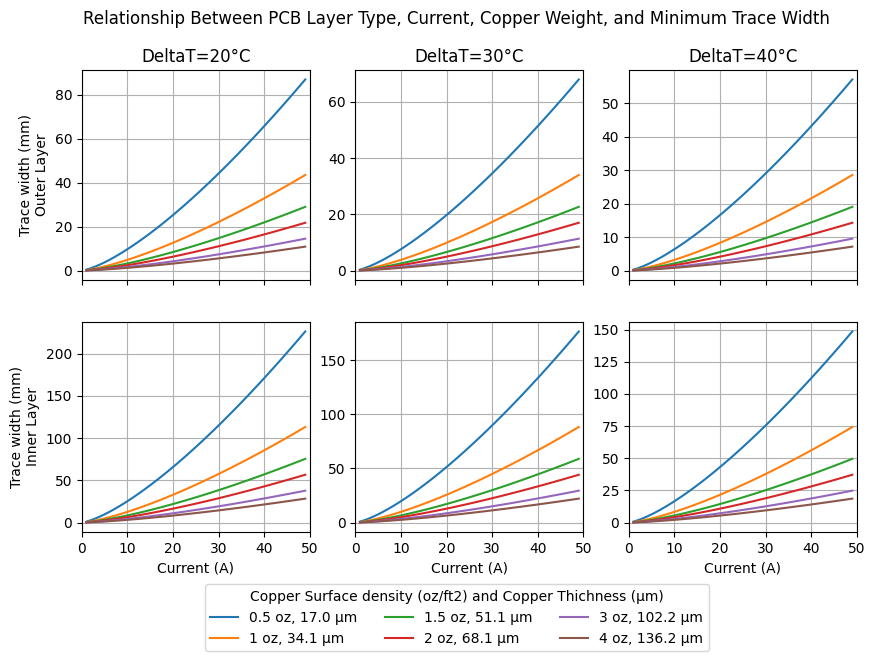

In [5]:
#fig, axs = plt.subplots(2,3,figsize=(10,6))
fig, axs = plt.subplots(2, 3, figsize=(10, 6), sharex=True)






Iarr= np.arange(1,50,1)
import numpy as np
for ik, kind in enumerate(("outer", "inner")):
    for it, DT in enumerate ((20,30,40)):
        ax = axs[ik][it]
        for oz in (0.5,1,1.5,2,3,4):
            arr=[]
            for I in Iarr:
                thickness_um = 68.114*oz/2
                
                #i= ipc2221current(wmm=2, thicknessum=thickness_um, DT= 30, kind = "outer")
                
                Wmm= ipc2221_min_width(I=I, thicknessum=thickness_um, DT= DT, kind = kind)
                arr.append(Wmm)
            ax.plot(Iarr, arr, label =f"{oz} oz, { thickness_um:.1F} µm")
            # ax.set_title(f"{kind.capitalize()} DeltaT={DT}°C")
            if ik ==0: 
                ax.set_title(f"DeltaT={DT}°C")
        #ax.legend()
        ax.grid(which = "both")
        ax.set_xlim([0, 50])
handles, labels = ax.get_legend_handles_labels()
fig.suptitle("Relationship Between PCB Layer Type, Current, Copper Weight, and Minimum Trace Width")
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=3, 
    bbox_to_anchor=(0.5, -0.1), 
    title = "Copper Surface density (oz/ft2) and Copper Thichness (µm)"
)
for i in range(3):
    axs[1][i].set_xlabel("Current (A)")
#for i in range(2):
axs[0][0].set_ylabel("Trace width (mm)\nOuter Layer")
axs[1][0].set_ylabel("Trace width (mm)\nInner Layer")